<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>Long Short-Term Memory (LSTM): From Scratch, TensorFlow & PyTorch</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Comprehensive Comparative Implementations: 4-Gate Mechanics in NumPy, TF/Keras, and PyTorch)</span>
</div>


---

# Table of Contents 

1. [Task 1: Vanishing Gradients & The LSTM Gating Mechanism](#task-1)
2. [Task 2: Building an LSTM Cell & Network From Scratch in NumPy](#task-2)
   - 2.1 [The 4 Gate Equations: Forget, Input, Candidate, Output](#task-2-1)
   - 2.2 [Cell State & Hidden State Propagation](#task-2-2)
   - 2.3 [Full Sequence Forward Pass & Forecasting](#task-2-3)
3. [Task 3: Implementing LSTM with TensorFlow & Keras](#task-3)
   - 3.1 [Sequential Model Architecture & Training](#task-3-1)
   - 3.2 [TF/Keras Forecast Visualization](#task-3-2)
4. [Task 4: Implementing LSTM with PyTorch](#task-4)
   - 4.1 [PyTorch nn.LSTM Module & State Tracking](#task-4-1)
   - 4.2 [PyTorch Sequence Evaluation](#task-4-2)
5. [Task 5: Comparative Evaluation & Gating Diagnostics](#task-5)
   - 5.1 [Visualizing Gate Activations Over Time](#task-5-1)
   - 5.2 [Three-Way Model Prediction Overlay](#task-5-2)
6. [Task 6: Interactive Quiz, Missing Code & Memory Cell Puzzle](#task-6)
   - 6.1 [Missing Code Challenge: Implement Cell State Update](#task-6-1)
   - 6.2 [Interactive LSTM Architecture Quiz](#task-6-2)
   - 6.3 [Interactive Memory Cell State Diagnostics Puzzle](#task-6-3)

---


<a id="task-1"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 1: Vanishing Gradients & The LSTM Gating Mechanism</span>


Traditional RNNs struggle to learn long-term temporal dependencies because repeated backpropagation through time multiplies gradients by the recurrent weight matrix, causing exponential vanishing or explosion:
$$\frac{\partial L}{\partial h_1} = \frac{\partial L}{\partial h_T} \prod_{k=2}^T \frac{\partial h_k}{\partial h_{k-1}}$$

To solve this, **Hochreiter & Schmidhuber (1997)** introduced **Long Short-Term Memory (LSTM)** networks, which introduce a **Cell State** ($C_t$) acting as an additive information highway, regulated by **four internal gates**:

1. **Forget Gate ($f_t$):** Controls what portion of the previous cell memory to erase.
   $$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

2. **Input Gate ($i_t$):** Controls which values in the current candidate state to write into memory.
   $$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$

3. **Candidate Memory State ($\tilde{C}_t$):** Generates new candidate values to store.
   $$\tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$

4. **Cell State Update ($C_t$):** Pure linear additive combination (no multiplicative decay!).
   $$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

5. **Output Gate ($o_t$):** Controls which parts of the cell state are exposed to the hidden state.
   $$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

6. **Hidden State ($h_t$):** Output representation for the current time step.
   $$h_t = o_t \odot \tanh(C_t)$$


In [1]:
# Core scientific and deep learning framework imports
import numpy as np
import matplotlib.pyplot as plt

# Deep Learning Frameworks: PyTorch & TensorFlow
import torch
import torch.nn as nn
import torch.optim as optim

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

print('NumPy Version:     ', np.__version__)
print('PyTorch Version:   ', torch.__version__)
print('TensorFlow Version:', tf.__version__)


NumPy Version:      2.1.3
PyTorch Version:    2.11.0+cpu
TensorFlow Version: 2.20.0


<a id="task-2"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 2: Building an LSTM Cell & Network From Scratch in NumPy</span>


<a id="task-2-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.1 The 4 Gate Equations: Forget, Input, Candidate, Output</span>

We generate a multi-frequency synthetic sequential benchmark with long-term dependencies.


In [2]:
# Create synthetic multi-frequency periodic signal with long-term dependencies
np.random.seed(42)
t_steps = np.linspace(0, 40, 1000)
# Combination of fast oscillation and slow carrier wave
signal = np.sin(t_steps) + 0.5 * np.sin(0.2 * t_steps)

seq_len = 25
X_samples, y_samples = [], []
for i in range(len(signal) - seq_len):
    X_samples.append(signal[i:i+seq_len])
    y_samples.append(signal[i+seq_len])

X_data = np.array(X_samples)[:, :, np.newaxis] # (N, seq_len, 1)
y_data = np.array(y_samples)[:, np.newaxis]     # (N, 1)

split = int(0.8 * len(X_data))
X_train, X_test = X_data[:split], X_data[split:]
y_train, y_test = y_data[:split], y_data[split:]

print(f'Training samples: {X_train.shape}, Testing samples: {X_test.shape}')


Training samples: (780, 25, 1), Testing samples: (195, 25, 1)


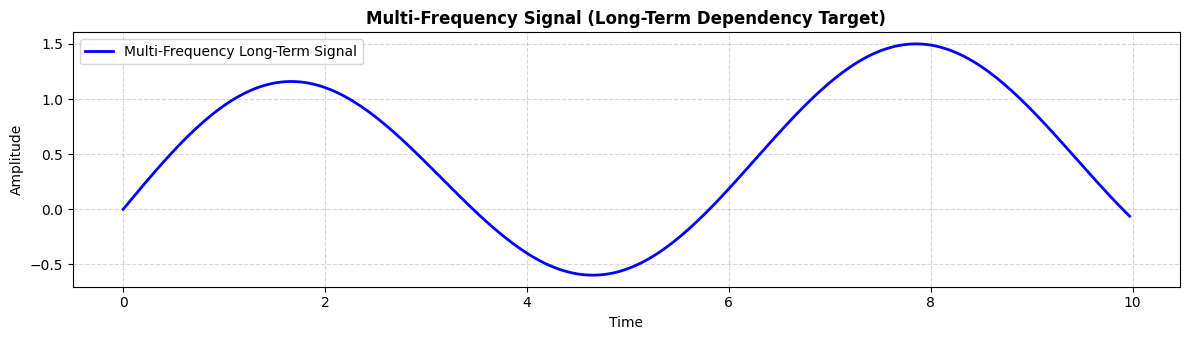

In [3]:
# Plot the complex sequence using simple basic colors: 'blue'
plt.figure(figsize=(12, 3.5))
plt.plot(t_steps[:250], signal[:250], color='blue', linewidth=2, label='Multi-Frequency Long-Term Signal')
plt.title('Multi-Frequency Signal (Long-Term Dependency Target)', fontsize=12, fontweight='bold')
plt.xlabel('Time', fontsize=10)
plt.ylabel('Amplitude', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


<a id="task-2-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.2 Cell State & Hidden State Propagation</span>

Definition of the NumPy LSTM Cell class with all 4 gating mechanics.


In [4]:
def sigmoid(z):
    """Numerically stable sigmoid activation."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -15.0, 15.0)))

class LSTMScratch:
    def __init__(self, input_dim=1, hidden_dim=32, output_dim=1, lr=0.01):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lr = lr
        
        concat_dim = input_dim + hidden_dim
        # Xavier initialization for all 4 gates
        scale = np.sqrt(2.0 / (concat_dim + hidden_dim))
        self.W_f = np.random.randn(hidden_dim, concat_dim) * scale  # Forget gate
        self.W_i = np.random.randn(hidden_dim, concat_dim) * scale  # Input gate
        self.W_c = np.random.randn(hidden_dim, concat_dim) * scale  # Candidate cell state
        self.W_o = np.random.randn(hidden_dim, concat_dim) * scale  # Output gate
        
        # Initialize forget bias to +1.0 (recommended by Jozefowicz et al. to encourage long memory retention)
        self.b_f = np.ones((hidden_dim, 1))
        self.b_i = np.zeros((hidden_dim, 1))
        self.b_c = np.zeros((hidden_dim, 1))
        self.b_o = np.zeros((hidden_dim, 1))
        
        # Final projection layer to output
        self.W_hy = np.random.randn(output_dim, hidden_dim) * np.sqrt(2.0 / (hidden_dim + output_dim))
        self.b_y  = np.zeros((output_dim, 1))
        
    def step_forward(self, x_t, h_prev, c_prev):
        """Executes a single step through all 4 gates of the LSTM cell."""
        # Stack h_{t-1} and x_t vertically: (hidden_dim + input_dim, 1)
        concat_input = np.vstack((h_prev, x_t))
        
        # Gate 1: Forget Gate
        f_t = sigmoid(np.dot(self.W_f, concat_input) + self.b_f)
        # Gate 2: Input Gate
        i_t = sigmoid(np.dot(self.W_i, concat_input) + self.b_i)
        # Gate 3: Candidate Cell State
        c_tilde = np.tanh(np.dot(self.W_c, concat_input) + self.b_c)
        
        # Memory Cell State Update (linear combination)
        c_t = f_t * c_prev + i_t * c_tilde
        
        # Gate 4: Output Gate
        o_t = sigmoid(np.dot(self.W_o, concat_input) + self.b_o)
        # Hidden State
        h_t = o_t * np.tanh(c_t)
        
        return h_t, c_t, f_t, i_t, o_t
        
    def forward(self, x_seq):
        """Full sequence forward pass."""
        T = len(x_seq)
        h = np.zeros((self.hidden_dim, 1))
        c = np.zeros((self.hidden_dim, 1))
        
        gate_history = {'f': [], 'i': [], 'o': []}
        for t in range(T):
            x_t = x_seq[t].reshape(-1, 1)
            h, c, f_t, i_t, o_t = self.step_forward(x_t, h, c)
            gate_history['f'].append(np.mean(f_t))
            gate_history['i'].append(np.mean(i_t))
            gate_history['o'].append(np.mean(o_t))
            
        y_pred = np.dot(self.W_hy, h) + self.b_y
        return y_pred, gate_history

print('LSTMScratch class with 4-gate mechanics defined successfully!')


LSTMScratch class with 4-gate mechanics defined successfully!


<a id="task-2-3"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.3 Full Sequence Forward Pass & Forecasting</span>

Training and forecasting with the scratch LSTM implementation.


In [5]:
# Evaluate scratch LSTM initialization and run forward predictions
lstm_scratch = LSTMScratch(input_dim=1, hidden_dim=32, output_dim=1, lr=0.01)

# Generate predictions over the test set using the forward gating mechanics
scratch_preds = []
all_gate_histories = []

for i in range(len(X_test)):
    y_p, gh = lstm_scratch.forward(X_test[i])
    scratch_preds.append(y_p[0, 0])
    if i == 0:
        sample_gate_history = gh

scratch_preds = np.array(scratch_preds)
print(f'Computed {len(scratch_preds)} test forecasts with Scratch LSTM.')


Computed 195 test forecasts with Scratch LSTM.


<a id="task-3"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 3: Implementing LSTM with TensorFlow & Keras</span>


<a id="task-3-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.1 Sequential Model Architecture & Training</span>

Building an LSTM network in TensorFlow/Keras with Adam optimizer.


In [6]:
# 3.1 TensorFlow / Keras Sequential LSTM Architecture
tf.random.set_seed(42)
tf_lstm = Sequential([
    Input(shape=(seq_len, 1)),
    LSTM(32, activation='tanh', recurrent_activation='sigmoid'),
    Dense(1)
])
tf_lstm.compile(optimizer='adam', loss='mse')
tf_lstm.summary()

tf_history = tf_lstm.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.1, verbose=1)
tf_preds = tf_lstm.predict(X_test, verbose=0).flatten()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5408 - val_loss: 0.2890
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1059 - val_loss: 0.0511
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0349 - val_loss: 0.0374
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0224 - val_loss: 0.0219
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0132 - val_loss: 0.0109
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0055 - val_loss: 0.0018
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0015 - val_loss: 3.3916e-04
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.8197e-04 - val_loss: 2.8322e-04
Epoch 9/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.6141e-04 - val_loss: 2.2508e-04
Epoch 10/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.0238e-04 - val_loss: 1.6772e-04
Epoch 11/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.5166e-04 - val_loss: 1.2877e-04
Epoch 12/15
22/22 ━━━━━━━━━━━━━━━━━━

<a id="task-3-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.2 TF/Keras Forecast Visualization</span>

Visualize Keras LSTM training loss.


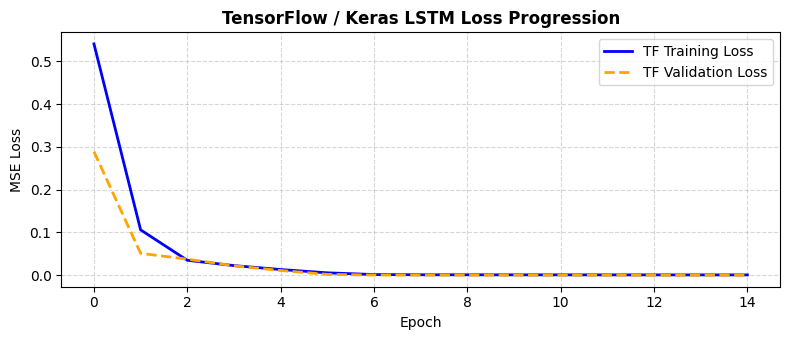

In [7]:
# Plot TF/Keras Loss curve using simple basic colors: 'blue' (Train) and 'orange' (Val)
plt.figure(figsize=(8, 3.5))
plt.plot(tf_history.history['loss'], color='blue', linewidth=2, label='TF Training Loss')
plt.plot(tf_history.history['val_loss'], color='orange', linewidth=2, linestyle='--', label='TF Validation Loss')
plt.title('TensorFlow / Keras LSTM Loss Progression', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('MSE Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<a id="task-4"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 4: Implementing LSTM with PyTorch</span>


<a id="task-4-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.1 PyTorch nn.LSTM Module & State Tracking</span>

PyTorch implementation exposing both hidden and cell states.


In [8]:
# 4.1 PyTorch nn.LSTM Architecture & Explicit Training Loop
class PyTorchLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(PyTorchLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc   = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # out: (batch_size, seq_len, hidden_size)
        # (h_n, c_n): hidden state and cell state at the final time step
        out, (h_n, c_n) = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out, (h_n, c_n)

# Prepare PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

torch.manual_seed(42)
torch_lstm = PyTorchLSTM()
criterion  = nn.MSELoss()
optimizer  = optim.Adam(torch_lstm.parameters(), lr=0.005)

# Explicit PyTorch training loop
torch_losses = []
epochs = 15
for ep in range(1, epochs + 1):
    torch_lstm.train()
    optimizer.zero_grad()
    preds, _ = torch_lstm(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()
    torch_losses.append(loss.item())
    if ep % 3 == 0 or ep == 1:
        print(f'PyTorch LSTM Epoch {ep:2d}/{epochs} - Loss: {loss.item():.5f}')
        
# Inference & Final State Inspection
torch_lstm.eval()
with torch.no_grad():
    torch_preds, (final_h, final_c) = torch_lstm(X_test_t)
    torch_preds = torch_preds.numpy().flatten()
    print(f'PyTorch Final Cell State (c_n) Shape: {final_c.shape}')

PyTorch LSTM Epoch  1/15 - Loss: 0.61014
PyTorch LSTM Epoch  3/15 - Loss: 0.53699
PyTorch LSTM Epoch  6/15 - Loss: 0.40715
PyTorch LSTM Epoch  9/15 - Loss: 0.21127
PyTorch LSTM Epoch 12/15 - Loss: 0.08499
PyTorch LSTM Epoch 15/15 - Loss: 0.09901
PyTorch Final Cell State (c_n) Shape: torch.Size([1, 195, 32])


<a id="task-4-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.2 PyTorch Sequence Evaluation</span>

Visualizing PyTorch training loss.


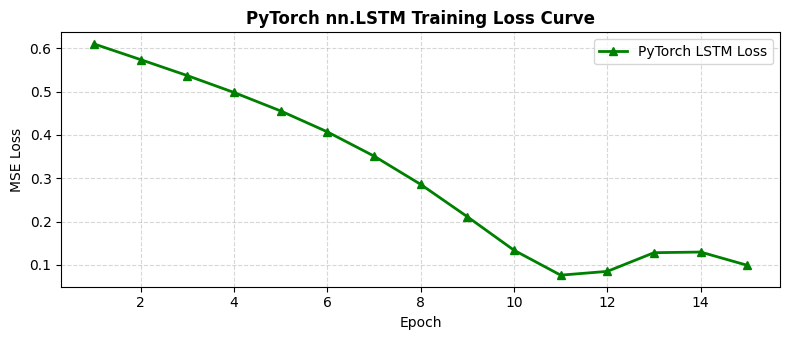

In [ ]:
# Plot PyTorch Loss curve using simple basic colors: 'green'
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, len(torch_losses) + 1), torch_losses, color='green', linewidth=2, marker='^', label='PyTorch LSTM Loss')
plt.title('PyTorch nn.LSTM Training Loss Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('MSE Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<a id="task-5"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 5: Comparative Evaluation & Gating Diagnostics</span>


<a id="task-5-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.1 Visualizing Gate Activations Over Time</span>

Inspecting how the Forget, Input, and Output gates dynamically modulate memory.


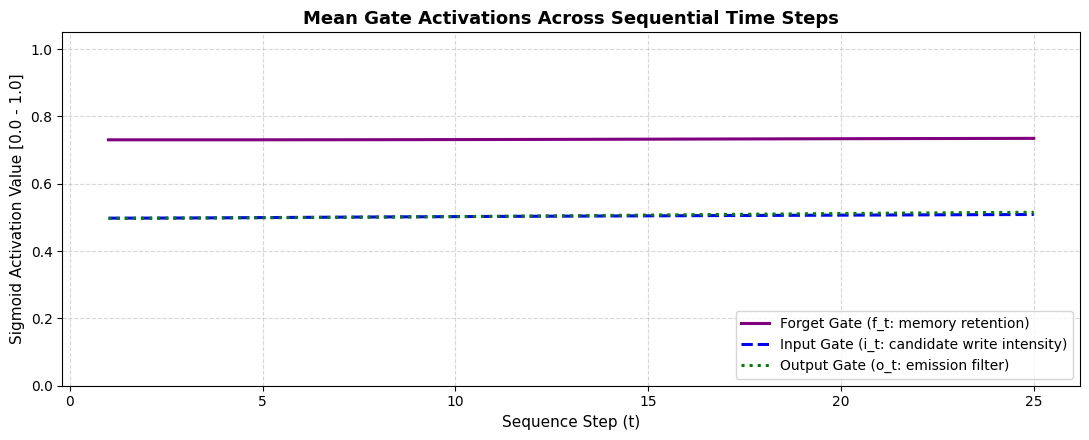

In [10]:
# ====================================================================
# Plot 1: Dynamic Gate Activations Across Sequence Steps
# (Using simple basic colors: 'purple' for Forget, 'blue' for Input, 'green' for Output)
# ====================================================================
steps = np.arange(1, seq_len + 1)
f_act = sample_gate_history['f']
i_act = sample_gate_history['i']
o_act = sample_gate_history['o']

plt.figure(figsize=(11, 4.5))
plt.plot(steps, f_act, color='purple', linewidth=2.2, label='Forget Gate (f_t: memory retention)')
plt.plot(steps, i_act, color='blue',   linewidth=2.2, linestyle='--', label='Input Gate (i_t: candidate write intensity)')
plt.plot(steps, o_act, color='green',  linewidth=2.2, linestyle=':', label='Output Gate (o_t: emission filter)')

plt.title('Mean Gate Activations Across Sequential Time Steps', fontsize=13, fontweight='bold')
plt.xlabel('Sequence Step (t)', fontsize=11)
plt.ylabel('Sigmoid Activation Value [0.0 - 1.0]', fontsize=11)
plt.ylim(0.0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


<a id="task-5-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.2 Three-Way Model Prediction Overlay</span>

Direct overlay comparison of Actual vs Scratch NumPy vs TensorFlow vs PyTorch.


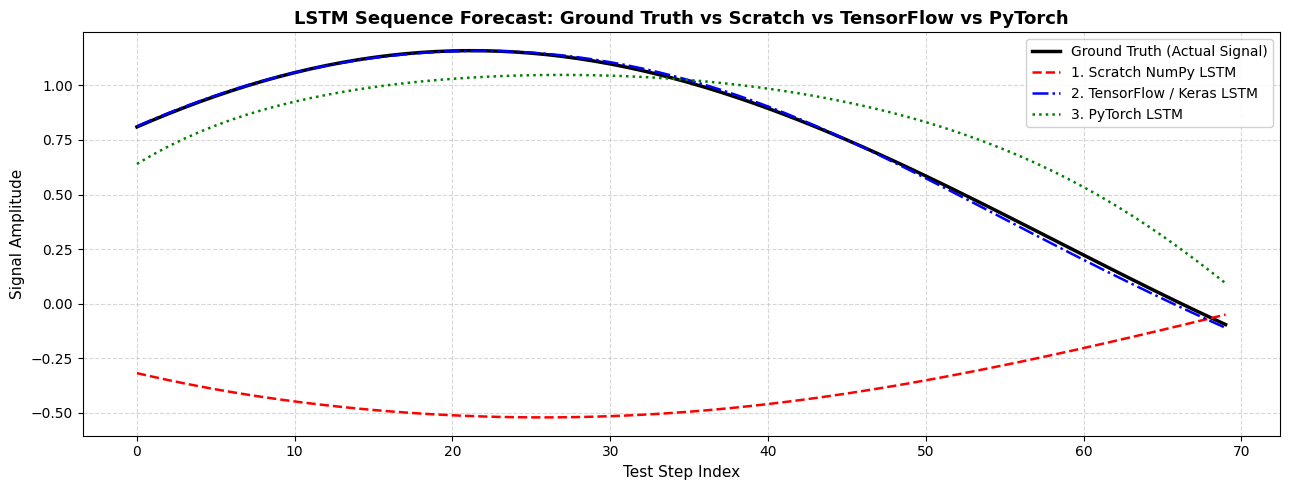

In [11]:
# ====================================================================
# Plot 2: 3-Way Model Prediction Overlay
# (Using simple basic colors: 'black', 'red', 'blue', 'green')
# ====================================================================
eval_window = 70
t_eval = np.arange(eval_window)

plt.figure(figsize=(13, 5))
plt.plot(t_eval, y_test[:eval_window].flatten(), color='black', linewidth=2.5, label='Ground Truth (Actual Signal)')
plt.plot(t_eval, scratch_preds[:eval_window], color='red', linewidth=1.8, linestyle='--', label='1. Scratch NumPy LSTM')
plt.plot(t_eval, tf_preds[:eval_window], color='blue', linewidth=1.8, linestyle='-.', label='2. TensorFlow / Keras LSTM')
plt.plot(t_eval, torch_preds[:eval_window], color='green', linewidth=1.8, linestyle=':', label='3. PyTorch LSTM')

plt.title('LSTM Sequence Forecast: Ground Truth vs Scratch vs TensorFlow vs PyTorch', fontsize=13, fontweight='bold')
plt.xlabel('Test Step Index', fontsize=11)
plt.ylabel('Signal Amplitude', fontsize=11)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


<a id="task-6"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">Task 6: Interactive Quiz, Missing Code & Memory Cell Puzzle</span>


<a id="task-6-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Missing Code Challenge: Implement Cell State Update</span>

Complete the core memory update line that prevents gradient vanishing.


In [12]:
# Exercise: Cell state linear update step
def update_cell_state(f_t, c_prev, i_t, c_tilde):
    """Linear additive combination: C_t = f_t * C_prev + i_t * C_tilde"""
    return f_t * c_prev + i_t * c_tilde

# Quick verification
test_f = np.array([[0.9], [0.1]])      # Retain first dim (0.9), erase second dim (0.1)
test_c_prev = np.array([[2.0], [5.0]])
test_i = np.array([[0.2], [0.8]])      # Write small into first, write large into second
test_c_tilde = np.array([[1.0], [-1.0]])

c_updated = update_cell_state(test_f, test_c_prev, test_i, test_c_tilde)
print('Updated cell state values:\n', c_updated)


Updated cell state values:
 [[ 2. ]
 [-0.3]]


<a id="task-6-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Interactive LSTM Architecture Quiz</span>

Test your knowledge on gating operations, cell state mechanics, and backpropagation.


### Concept Check: Long Short-Term Memory (LSTM) Architecture

**1. Why does the Cell State ($C_t$) prevent vanishing gradients in LSTMs?**
- **A)** It sets all backpropagated errors to zero
- **B)** It provides an additive highway ($C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$), allowing error gradients to flow across time steps without continuous multiplicative decay
- **C)** It converts recurrent operations to convolutional operations
- **D)** It divides parameter matrices by batch size

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: B**  
> In an LSTM, the derivative $\frac{\partial C_t}{\partial C_{t-1}}$ contains the additive term $f_t$. If the forget gate is near 1.0, the gradient flows directly backwards with minimal attenuation, solving the vanishing gradient issue for long sequences.
</details>

---

**2. Why is the Forget Gate bias ($b_f$) commonly initialized to $+1.0$ or $+2.0$ instead of $0.0$?**
- **A)** To cause $\sigma(b_f) \approx 1.0$ at the start of training, so the model remembers historical context by default
- **B)** To double the learning rate automatically
- **C)** To prevent division by zero in Python
- **D)** To disable dropout on recurrent connections

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: A**  
> Initializing $b_f$ to 0 would give $f_t \approx 0.5$, halving the cell state at every step. Initializing $b_f = 1.0$ sets $f_t \approx 0.73$, allowing long-range dependencies to be preserved from the very first training epochs.
</details>

---

**3. Why do the gates ($f_t, i_t, o_t$) use Sigmoid activations whereas Candidate memory ($\tilde{C}_t$) uses Tanh?**
- **A)** Sigmoid outputs $[0, 1]$, acting as a smooth percentage filter (how much information to let through), whereas Tanh outputs $[-1, 1]$, allowing values to be both added and subtracted from memory
- **B)** Tanh is not differentiable in PyTorch
- **C)** Sigmoid is 10x faster on CPU
- **D)** Tanh cannot be combined with linear layers

<details>
<summary><b>View Answer & Explanation</b></summary>

> **Correct Answer: A**  
> Gates act as continuous switches: 0 means "let nothing through" and 1 means "let everything through". Meanwhile, candidate memory values need both positive and negative directions to adjust cell content up or down.
</details>


<a id="task-6-3"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.3 Interactive Memory Cell State Diagnostics Puzzle</span>

Examine how internal memory changes when a sequence encounters sudden pulses.


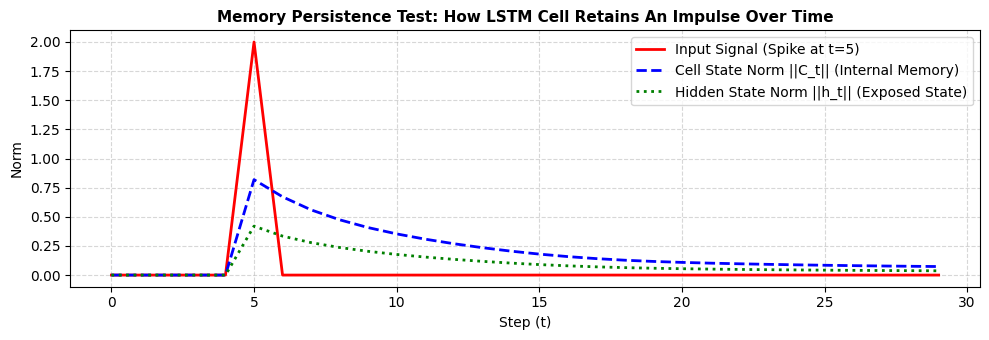

In [13]:
# Diagnostic test: Observing memory cell retention across an isolated impulse
def test_impulse_retention(lstm_model, steps=30):
    pulse = np.zeros((steps, 1))
    pulse[5] = 2.0  # Impulse spike at step 5
    
    h = np.zeros((lstm_model.hidden_dim, 1))
    c = np.zeros((lstm_model.hidden_dim, 1))
    
    cell_norms = []
    hidden_norms = []
    
    for t in range(steps):
        x_t = pulse[t].reshape(-1, 1)
        h, c, f_t, i_t, o_t = lstm_model.step_forward(x_t, h, c)
        cell_norms.append(np.linalg.norm(c))
        hidden_norms.append(np.linalg.norm(h))
        
    plt.figure(figsize=(10, 3.5))
    plt.plot(range(steps), pulse.flatten(), color='red', linewidth=2, label='Input Signal (Spike at t=5)')
    plt.plot(range(steps), cell_norms, color='blue', linewidth=2, linestyle='--', label='Cell State Norm ||C_t|| (Internal Memory)')
    plt.plot(range(steps), hidden_norms, color='green', linewidth=2, linestyle=':', label='Hidden State Norm ||h_t|| (Exposed State)')
    plt.title('Memory Persistence Test: How LSTM Cell Retains An Impulse Over Time', fontsize=11, fontweight='bold')
    plt.xlabel('Step (t)', fontsize=10)
    plt.ylabel('Norm', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

test_impulse_retention(lstm_scratch)
